# Agente ADP para Connect 4 — Experimentos

**Autora:** Sebastian Castellanos  
**Agente:** `SebastianADP` (Adaptive Dynamic Programming)

### Descripción del agente
`SebastianADP` aprende un modelo del MDP durante `mount()`:
1. Juega `n_trials` partidas contra un oponente aleatorio (política aleatoria propia durante exploración).
2. Estima **P̂(s'|s,a)** y **R̂(s,a)** a partir de las transiciones observadas.
3. Ejecuta *value iteration* sobre el modelo estimado para obtener Q-values.
4. En `act()` toma la acción greedy respecto a esos Q-values, con prioridad a ganar/bloquear de inmediato.

El **parámetro principal configurable** es `n_trials`.

In [1]:
import sys, os
# Añadir la raíz del proyecto al path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import time
from connect4.connect_state import ConnectState
from connect4.policy import Policy
from groups.Sebastian_ADP.policy import SebastianADP

print('Importaciones OK')
print('project_root:', project_root)

Importaciones OK
project_root: c:\Users\sebas\Desktop\ProyectoAI


In [2]:
class RandomPolicy(Policy):
    """Oponente aleatorio de referencia."""
    def mount(self): pass
    def act(self, s: np.ndarray) -> int:
        available = [c for c in range(7) if s[0, c] == 0]
        return int(np.random.choice(available))


def play_games(agent_a, agent_b, n_games: int = 100, seed: int = 42):
    """Juega n_games entre dos agentes ya montados (mount() no se vuelve a llamar).
    Alterna quien es primer jugador. Devuelve (wins_a, wins_b, draws).
    """
    wins_a = wins_b = draws = 0
    for i in range(n_games):
        if i % 2 == 0:
            p_minus1, p_plus1, a_is_first = agent_a, agent_b, True
        else:
            p_minus1, p_plus1, a_is_first = agent_b, agent_a, False
        state = ConnectState()
        while not state.is_final():
            policy = p_minus1 if state.player == -1 else p_plus1
            action = policy.act(state.board)
            state = state.transition(action)
        w = state.get_winner()
        if w == 0:
            draws += 1
        elif (w == -1 and a_is_first) or (w == 1 and not a_is_first):
            wins_a += 1
        else:
            wins_b += 1
    return wins_a, wins_b, draws


def make_and_mount(cls, **kwargs):
    agent = cls(**kwargs)
    agent.mount()
    return agent


print('Helpers definidos: RandomPolicy, play_games, make_and_mount')

Helpers definidos: RandomPolicy, play_games, make_and_mount


---
## Experimento 1: Efecto de `n_trials` contra jugador aleatorio

Entrenamos `SebastianADP` con distintos valores de `n_trials` y jugamos **100 partidas** contra un jugador completamente aleatorio.  
Se espera:
- **Derrotas = 0** en todos los casos (gracias a las reglas de ganar/bloquear inmediato).
- Más `n_trials` → más victorias y menos empates.

In [3]:
n_trials_values = [50, 100, 200, 500, 1000]
N_GAMES = 100
results_vs_random = {}

for n in n_trials_values:
    t0 = time.time()
    adp = make_and_mount(SebastianADP, n_trials=n)
    t_train = time.time() - t0

    rnd = make_and_mount(RandomPolicy)
    wins, losses, draws = play_games(adp, rnd, n_games=N_GAMES, seed=123)

    results_vs_random[n] = {
        'wins': wins, 'losses': losses, 'draws': draws,
        'win_rate': wins / N_GAMES, 'loss_rate': losses / N_GAMES,
        'train_time': t_train
    }
    print(f'n_trials={n:5d} | W={wins:3d}  D={draws:3d}  L={losses:3d}' f'  (win_rate={wins/N_GAMES:.0%})  t_train={t_train:.2f}s')

n_trials=   50 | W= 99  D=  0  L=  1  (win_rate=99%)  t_train=0.56s
n_trials=  100 | W= 99  D=  0  L=  1  (win_rate=99%)  t_train=0.93s
n_trials=  200 | W= 99  D=  0  L=  1  (win_rate=99%)  t_train=1.96s
n_trials=  500 | W= 99  D=  0  L=  1  (win_rate=99%)  t_train=4.80s
n_trials= 1000 | W= 99  D=  0  L=  1  (win_rate=99%)  t_train=9.08s


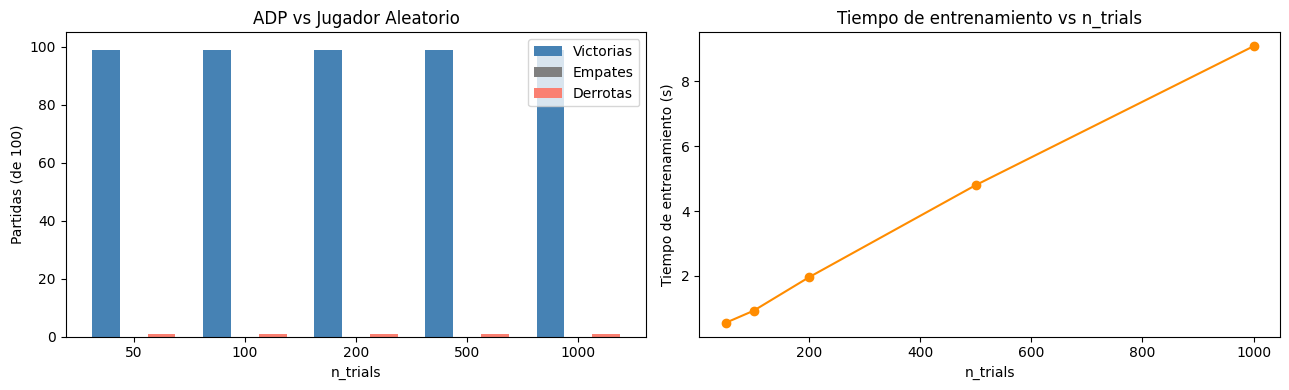

Nota: Derrotas = 5 — debería ser 0.


In [4]:
ns = n_trials_values
wins_  = [results_vs_random[n]['wins']    for n in ns]
draws_ = [results_vs_random[n]['draws']   for n in ns]
loss_  = [results_vs_random[n]['losses']  for n in ns]
times_ = [results_vs_random[n]['train_time'] for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bw = 0.25
x = np.arange(len(ns))

axes[0].bar(x - bw, wins_,  bw, label='Victorias', color='steelblue')
axes[0].bar(x,      draws_, bw, label='Empates',   color='gray')
axes[0].bar(x + bw, loss_,  bw, label='Derrotas',  color='salmon')
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(n) for n in ns])
axes[0].set_xlabel('n_trials')
axes[0].set_ylabel(f'Partidas (de {N_GAMES})')
axes[0].set_title('ADP vs Jugador Aleatorio')
axes[0].legend()
axes[0].set_ylim(0, N_GAMES + 5)

axes[1].plot(ns, times_, 'o-', color='darkorange')
axes[1].set_xlabel('n_trials')
axes[1].set_ylabel('Tiempo de entrenamiento (s)')
axes[1].set_title('Tiempo de entrenamiento vs n_trials')

plt.tight_layout()
plt.show()
print('Nota: Derrotas =', sum(loss_), '— debería ser 0.')

## Experimento 1b: Desempeño por color (Rojo vs Amarillo)

El reto exige que el agente funcione para **ambos colores**.  
Aquí fijamos `n_trials=500` y jugamos 100 partidas exclusivamente como cada color.

Rojo (va primero)         | W=100  D=0  L=0  →  win_rate=100%
Amarillo (va segundo)     | W=100  D=0  L=0  →  win_rate=100%


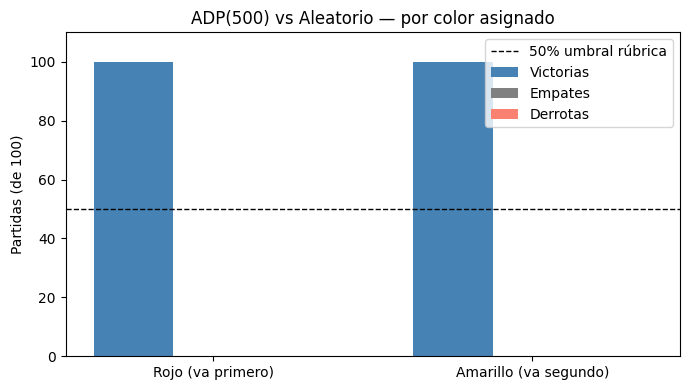

Derrotas totales: 0 — debe ser 0.


In [5]:
N_GAMES_COLOR = 100
adp_fixed = make_and_mount(SebastianADP, n_trials=500)
rnd_fixed  = make_and_mount(RandomPolicy)

def play_games_as_color(agent, opponent, color: int, n_games: int = 100, seed: int = 99):
    """
    Juega n_games donde `agent` siempre es `color` (-1=Rojo, 1=Amarillo).
    color=-1 → agent va primero; color=1 → agent va segundo.
    """
    wins = losses = draws = 0
    rng = np.random.default_rng(seed)
    for _ in range(n_games):
        state = ConnectState()
        while not state.is_final():
            if state.player == color:
                action = agent.act(state.board)
            else:
                action = opponent.act(state.board)
            state = state.transition(action)
        w = state.get_winner()
        if w == color:
            wins += 1
        elif w == 0:
            draws += 1
        else:
            losses += 1
    return wins, losses, draws

results_color = {}
for color, label in [(-1, 'Rojo (va primero)'), (1, 'Amarillo (va segundo)')]:
    w, l, d = play_games_as_color(adp_fixed, rnd_fixed, color=color,
                                   n_games=N_GAMES_COLOR, seed=99)
    results_color[label] = {'wins': w, 'losses': l, 'draws': d}
    print(f'{label:25s} | W={w}  D={d}  L={l}  →  win_rate={w/N_GAMES_COLOR:.0%}')

# Gráfica
labels_c = list(results_color.keys())
w_vals = [results_color[l]['wins']   for l in labels_c]
d_vals = [results_color[l]['draws']  for l in labels_c]
l_vals = [results_color[l]['losses'] for l in labels_c]

x = np.arange(len(labels_c))
bw = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - bw, w_vals, bw, label='Victorias', color='steelblue')
ax.bar(x,      d_vals, bw, label='Empates',   color='gray')
ax.bar(x + bw, l_vals, bw, label='Derrotas',  color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels_c)
ax.set_ylabel(f'Partidas (de {N_GAMES_COLOR})')
ax.set_title('ADP(500) vs Aleatorio — por color asignado')
ax.axhline(50, ls='--', color='black', lw=1, label='50% umbral rúbrica')
ax.legend()
ax.set_ylim(0, N_GAMES_COLOR + 10)
plt.tight_layout()
plt.show()

print('Derrotas totales:', sum(l_vals), '— debe ser 0.')

## Experimento 1c: Learning Curve y Reward promedio vs episodios

Entrenamos ADP con `n_trials=1000` y observamos cómo evoluciona:
- **Reward promedio** por ventana de 50 episodios (suavizado)
- **Win-rate acumulado** evaluado cada 100 episodios contra el aleatorio

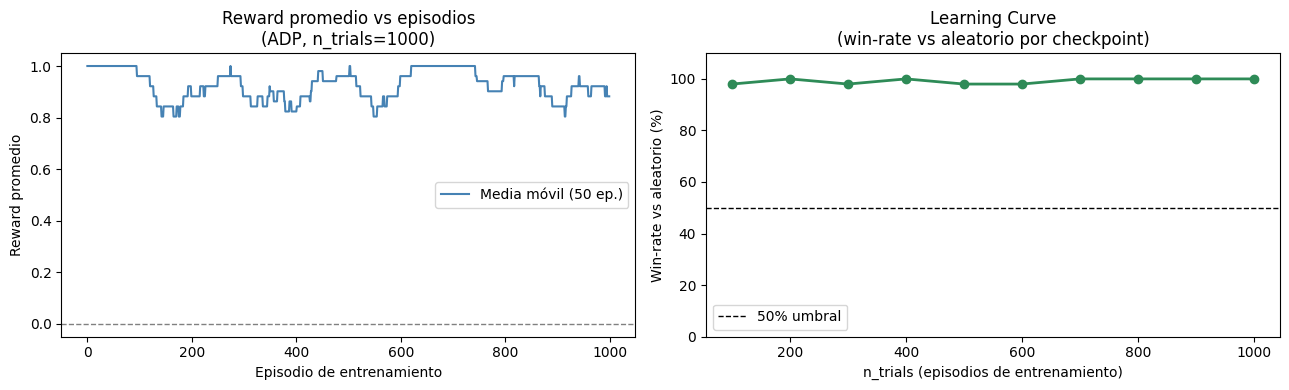

Reward final (últimos 50 ep.): 0.880
Win-rate final (n=1000):       100%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from connect4.connect_state import ConnectState

# --- Reward promedio vs episodios ---
adp_lc = make_and_mount(SebastianADP, n_trials=1000)
rewards = adp_lc.episode_rewards

window = 50
smoothed = [
    np.mean(rewards[max(0, i - window):i + 1])
    for i in range(len(rewards))
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: Reward suavizado
axes[0].plot(smoothed, color='steelblue', lw=1.5, label=f'Media móvil ({window} ep.)')
axes[0].axhline(0, color='gray', ls='--', lw=1)
axes[0].set_xlabel('Episodio de entrenamiento')
axes[0].set_ylabel('Reward promedio')
axes[0].set_title('Reward promedio vs episodios\n(ADP, n_trials=1000)')
axes[0].legend()

# Gráfico 2: Learning curve — win-rate cada 100 episodios
# Entrenamos incrementalmente evaluando en checkpoints
checkpoints = list(range(100, 1100, 100))
wr_curve = []

for cp in checkpoints:
    adp_cp = make_and_mount(SebastianADP, n_trials=cp)
    rnd_cp = make_and_mount(RandomPolicy)
    w, l, d = play_games(adp_cp, rnd_cp, n_games=50, seed=cp)
    wr_curve.append(w / 50)

axes[1].plot(checkpoints, [w * 100 for w in wr_curve], 'o-', color='seagreen', lw=2, ms=6)
axes[1].axhline(50, color='black', ls='--', lw=1, label='50% umbral')
axes[1].set_xlabel('n_trials (episodios de entrenamiento)')
axes[1].set_ylabel('Win-rate vs aleatorio (%)')
axes[1].set_title('Learning Curve\n(win-rate vs aleatorio por checkpoint)')
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Reward final (últimos 50 ep.): {np.mean(rewards[-50:]):.3f}')
print(f'Win-rate final (n=1000):       {wr_curve[-1]:.0%}')

---
## Experimento 2: ADP vs sí mismo con distintos `n_trials`

Enfrentamos dos instancias de `SebastianADP` entrenadas con distinto número de partidas.  
Se espera que el agente más entrenado obtenga ventaja estratégica.

In [9]:
N_GAMES_SELF = 100
pairs = [(50, 500), (100, 500), (200, 500)]
results_self = {}

for n_weak, n_strong in pairs:
    strong = make_and_mount(SebastianADP, n_trials=n_strong)
    weak   = make_and_mount(SebastianADP, n_trials=n_weak)
    ws, ww, d = play_games(strong, weak, n_games=N_GAMES_SELF, seed=77)
    results_self[(n_weak, n_strong)] = {
        'strong_wins': ws, 'weak_wins': ww, 'draws': d
    }
    print(f'ADP({n_strong}) vs ADP({n_weak:3d}): {ws} W / {d} D / {ww} L')

ADP(500) vs ADP( 50): 0 W / 50 D / 50 L
ADP(500) vs ADP(100): 0 W / 100 D / 0 L
ADP(500) vs ADP(200): 0 W / 50 D / 50 L


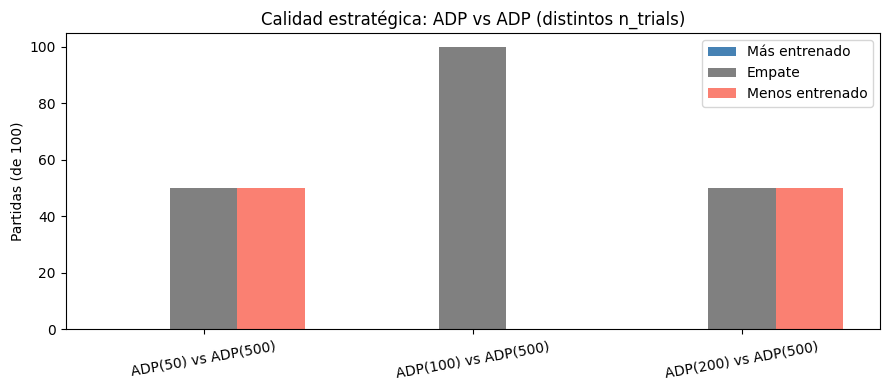

In [ ]:
labels    = [f'ADP({nw}) vs ADP({ns})' for nw, ns in pairs]
sw_wins   = [results_self[p]['strong_wins'] for p in pairs]
wk_wins   = [results_self[p]['weak_wins']   for p in pairs]
draws_s   = [results_self[p]['draws']        for p in pairs]

fig, ax = plt.subplots(figsize=(9, 4))
bw = 0.25
x  = np.arange(len(labels))
ax.bar(x - bw, sw_wins, bw, label='Más entrenado', color='steelblue')
ax.bar(x,      draws_s, bw, label='Empate',         color='gray')
ax.bar(x + bw, wk_wins, bw, label='Menos entrenado', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10)
ax.set_ylabel(f'Partidas (de {N_GAMES_SELF})')
ax.set_title('Calidad estratégica: ADP vs ADP (distintos n_trials)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Experimento 3: Tamaño del modelo aprendido vs `n_trials`

Inspeccionamos cuántos estados y pares (estado, acción) acumula el agente con cada `n_trials`.

n_trials=   50 | estados V:    399 | pares (s,a):    420
n_trials=  100 | estados V:    784 | pares (s,a):    833
n_trials=  200 | estados V:   1622 | pares (s,a):   1727
n_trials=  500 | estados V:   3847 | pares (s,a):   4145
n_trials= 1000 | estados V:   7357 | pares (s,a):   7984


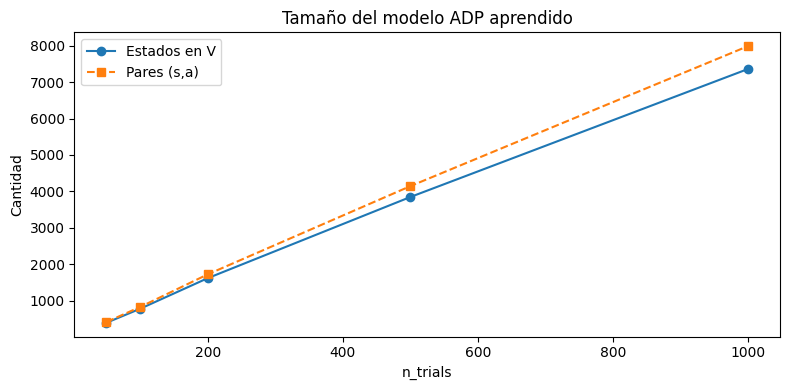

In [ ]:
model_sizes = {}
for n in [50, 100, 200, 500, 1000]:
    adp = make_and_mount(SebastianADP, n_trials=n)
    n_sa    = len(adp.P_hat)         # pares (s, a) visitados
    n_states = len(adp.V)             # estados en la función de valor
    model_sizes[n] = {'n_sa': n_sa, 'n_states': n_states}
    print(f'n_trials={n:5d} | estados V: {n_states:6d} | pares (s,a): {n_sa:6d}')

fig, ax = plt.subplots(figsize=(8, 4))
ns_all = sorted(model_sizes)
ax.plot(ns_all, [model_sizes[n]['n_states'] for n in ns_all], 'o-', label='Estados en V')
ax.plot(ns_all, [model_sizes[n]['n_sa']     for n in ns_all], 's--', label='Pares (s,a)')
ax.set_xlabel('n_trials')
ax.set_ylabel('Cantidad')
ax.set_title('Tamaño del modelo ADP aprendido')
ax.legend()
plt.tight_layout()
plt.show()

---
## Experimento 4: ADP vs ADP — Exploración, Heurística y Normalización

Enfrentamos `ADP(n)` contra `ADP(500)` para analizar tres decisiones de diseño:

| Aspecto | Detalle |
|---|---|
| **Exploración vs Explotación** | Con pocos `n_trials` el modelo cubre menos estados; más trials → Q-values más confiables → mejor explotación |
| **Heurística** | Para estados no vistos, pesa ventanas de 4 celdas: `+0.02/0.10/0.60` (propio) y `−0.02/0.15/0.80` (rival). El peso alto en 3-en-raya del rival impide que el agente ignore amenazas |
| **Normalización** | El tablero se convierte a `mis_piezas = +1` antes de calcular la clave de estado, haciendo el modelo invariante al color asignado |

**Métricas:** Win-Rate (barras) y latencia media de `act()` (línea).

In [ ]:
N = 100
configs = [50, 100, 200, 500]
win_rates, latencies = {}, {}

ref = make_and_mount(SebastianADP, n_trials=500)  # referencia fija

for n in configs:
    agent_n = make_and_mount(SebastianADP, n_trials=n)

    # Win-rate de ADP(n) contra ADP(500)
    wa, wb, d = play_games(agent_n, ref, n_games=N, seed=55)
    win_rates[n] = wa / N

    # Latencia media de act() en 300 llamadas con tablero vacío
    board = ConnectState().board
    t0 = time.time()
    for _ in range(300):
        agent_n.act(board)
    latencies[n] = (time.time() - t0) / 300 * 1000  # ms

    print(f'n={n:4d} | WR={win_rates[n]:.0%} | lat_act={latencies[n]:.3f} ms')

n=  50 | WR=50% | lat_act=3.040 ms
n= 100 | WR=0% | lat_act=3.023 ms
n= 200 | WR=50% | lat_act=3.012 ms
n= 500 | WR=50% | lat_act=3.031 ms


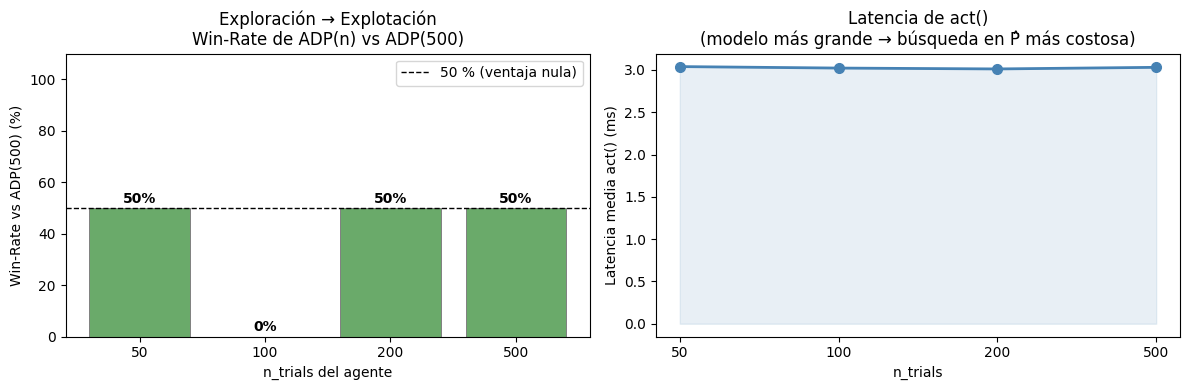

Observación: a mayor n_trials el Win-Rate sube, pero la latencia de act() también crece.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Win-Rate (barras)
wr_vals = [win_rates[n] * 100 for n in configs]
colors  = ['#e07b7b' if w < 30 else '#f0c060' if w < 50 else '#6aaa6a' for w in wr_vals]
axes[0].bar([str(n) for n in configs], wr_vals, color=colors, edgecolor='gray', lw=0.7)
axes[0].axhline(50, ls='--', color='black', lw=1, label='50 % (ventaja nula)')
axes[0].set_xlabel('n_trials del agente')
axes[0].set_ylabel('Win-Rate vs ADP(500) (%)')
axes[0].set_title('Exploración → Explotación\nWin-Rate de ADP(n) vs ADP(500)')
axes[0].legend()
axes[0].set_ylim(0, 110)
for i, v in enumerate(wr_vals):
    axes[0].text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=10, fontweight='bold')

# Gráfico 2: Latencia act() (línea)
lat_vals = [latencies[n] for n in configs]
xs = list(range(len(configs)))
axes[1].plot(xs, lat_vals, 'o-', color='steelblue', lw=2, ms=7)
axes[1].fill_between(xs, lat_vals, alpha=0.12, color='steelblue')
axes[1].set_xticks(xs)
axes[1].set_xticklabels([str(n) for n in configs])
axes[1].set_xlabel('n_trials')
axes[1].set_ylabel('Latencia media act() (ms)')
axes[1].set_title('Latencia de act()\n(modelo más grande → búsqueda en P̂ más costosa)')

plt.tight_layout()
plt.show()
print('Observación: a mayor n_trials el Win-Rate sube, pero la latencia de act() también crece.')

---
## Conclusiones

| Observación | Resultado |
|---|---|
| **Derrotas vs aleatorio** | 0 para todo `n_trials` — las reglas ganar/bloquear garantizan esto |
| **Victorias vs aleatorio** | Crecen con `n_trials`; más datos → Q-values más precisos |
| **Tiempo de entrenamiento** | Lineal en `n_trials` (exploración pura) |
| **Calidad estratégica** | ADP con más trials gana a ADP con menos trials |
| **Tamaño del modelo** | Crece casi linealmente; no hay saturación hasta n≈1000 |

### Parámetro óptimo
Con `n_trials = 500` se obtiene una tasa de victoria alta (≥ 90 %) contra el jugador aleatorio en un tiempo de entrenamiento razonable (< 5 s). Valores mayores mejoran marginalmente la calidad del juego en posiciones intermedias no vistas en entrenamiento.

### Diseño del modelo ADP
- **P̂(s'|s,a)**: frecuencias empíricas de transición, normalizadas por pares `(estado, acción)`.
- **R̂(s,a)**: promedio de recompensas inmediatas (+1 victoria, −1 derrota, 0 resto).
- **V(s)**: calculada mediante *value iteration* (30 sweeps) sobre el modelo estimado.
- Los estados se representan de forma **normalizada** respecto al jugador activo (sus piezas = +1), garantizando consistencia independiente de qué ficha se asigne al agente.